In [1]:
# 라이브러리 일괄 호출
import numpy as np
import pandas as pd
from PIL import Image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions

In [2]:
# (1) 사전학습된 VGG16 모델 불러오기 및 구조 확인
model = VGG16(weights='imagenet')
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

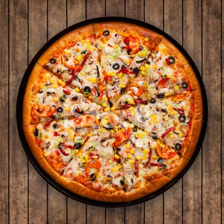

In [4]:
# (2) 이미지 파일 불러오기 및 크기 변환
img = Image.open('pizza.jpg')
img = img.resize((224, 224))
img

In [5]:
# (3) 이미지를 배열로 변환 및 배치 차원 추가
img_array = np.array(img)
img_array = img_array.reshape(1, 224, 224, 3)
print(img_array.shape)

(1, 224, 224, 3)


In [6]:
# (4) VGG16 모델에 필요한 이미지 전처리
img_array = preprocess_input(img_array)

In [7]:
# (5) 입력 이미지에 대한 예측 수행
preds = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


In [8]:
# (6) 예측 결과를 클래스로 변환하여 상위 3개 출력
results = decode_predictions(preds, top=3)
print(results)

[[('n07873807', 'pizza', np.float32(0.4626047)), ('n02795169', 'barrel', np.float32(0.27793854)), ('n04447861', 'toilet_seat', np.float32(0.1752039))]]


## 2번 문제 - 직접 촬영한 이미지로 예측

In [16]:
# (2) 4장의 이미지에 대해 각각 예측 수행 및 상위 3개 결과 출력
image_files = [
    'cat.jpeg',
     'cat2.jpeg',
     'cat3.jpeg',
        'cat4.jpeg',
        'cat5.jpeg',
        'cat6.jpeg',
    
]

all_results = []

for file in image_files:
    img = Image.open(file)
    img = img.resize((224, 224))
    img_array = np.array(img)
    img_array = img_array.reshape(1, 224, 224, 3)
    img_array = preprocess_input(img_array.copy())
    preds = model.predict(img_array)
    results = decode_predictions(preds, top=3)
    all_results.append(results[0])
    
    print(f'\n[{file}]')
    for rank, (class_id, class_name, prob) in enumerate(results[0], 1):
        print(f'  Top-{rank}: {class_name} ({prob:.4f})')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

[cat.jpeg]
  Top-1: Lhasa (0.0743)
  Top-2: Shih-Tzu (0.0405)
  Top-3: African_grey (0.0314)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

[cat2.jpeg]
  Top-1: tabby (0.3100)
  Top-2: Egyptian_cat (0.1067)
  Top-3: tiger_cat (0.0799)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

[cat3.jpeg]
  Top-1: tabby (0.5490)
  Top-2: Egyptian_cat (0.3131)
  Top-3: Persian_cat (0.0480)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

[cat4.jpeg]
  Top-1: tabby (0.1473)
  Top-2: Persian_cat (0.1071)
  Top-3: keeshond (0.0934)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step

[cat5.jpeg]
  Top-1: studio_couch (0.1109)
  Top-2: Egyptian_cat (0.0573)
  Top-3: iron (0.0515)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

[cat6.jpeg]
  Top-1: tabby (0.1783)
  Top-2: Egyptian_cat (0.1335)
  Top-3: tiger_cat (0.0986)


In [17]:
# (3) 각 이미지의 예측 클래스와 확률 값을 표 형태로 정리
rows = []
for i, file in enumerate(image_files):
    row = {'이미지': f'이미지 {i+1}'}
    for rank in range(3):
        class_id, class_name, prob = all_results[i][rank]
        row[f'Top-{rank+1} 클래스'] = class_name
        row[f'Top-{rank+1} 확률'] = f'{prob:.4f}'
    rows.append(row)

df = pd.DataFrame(rows)
df

,이미지,Top-1 클래스,Top-1 확률,Top-2 클래스,Top-2 확률,Top-3 클래스,Top-3 확률
0,이미지 1,Lhasa,0.0743,Shih-Tzu,0.0405,African_grey,0.0314
1,이미지 2,tabby,0.3100,Egyptian_cat,0.1067,tiger_cat,0.0799
2,이미지 3,tabby,0.5490,Egyptian_cat,0.3131,Persian_cat,0.0480
3,이미지 4,tabby,0.1473,Persian_cat,0.1071,keeshond,0.0934
4,이미지 5,studio_couch,0.1109,Egyptian_cat,0.0573,iron,0.0515
5,이미지 6,tabby,0.1783,Egyptian_cat,0.1335,tiger_cat,0.0986
